In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import os
from io import BytesIO
from urllib.request import urlopen
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.cluster import KMeans


# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

In [2]:
df = pd.read_csv(r"D:\FData\EPL_2024_25\epl_till_gw35.csv")

In [120]:
def plot_fentry_pass(ax, team_name):
    fentry = df[
                (df["teamName"] == team_name)
                & (df["type"].isin(["Pass", "Carry"]))
                & (df["outcomeType"] == "Successful")
                & (~df["qualifiers"].str.contains("Freekick|Corner"))
                & (df["x"]>35)
                & (
                    np.sqrt(
                        (df['x']-df['endX'])**2 + (df['y']-df['endY'])**2
                    ) >=5
                )
            ]

    fep = fentry[
        (fentry["type"] == "Pass")
        & (fentry["x"] < 70)
        & (fentry["endX"] > 70)
    ]
    fec = fentry[
        (fentry["type"] == "Carry")
        & (fentry["x"] < 70)
        & (fentry["endX"] > 70)
    ]
    tfent = pd.concat([fep, fec], ignore_index=True)

    kmeans = KMeans(n_clusters=5, random_state=0)
    fep['cluster'] = kmeans.fit_predict(fep[['x', 'y', 'endX', 'endY']])

    
    pitch = VerticalPitch(
        pitch_type="uefa",
        pitch_color=bg_color,
        line_color=line_color,
        linewidth=2,
        corner_arcs=True,
    )
    pitch.draw(ax=ax)

    # Define 6 custom colors
    color_ranked = ['#377eb8', '#f781bf', '#4daf4a', '#fcba03', col1]
    
    # Count lines per cluster (descending)
    cluster_counts = fep['cluster'].value_counts().sort_values(ascending=False)
    cluster_color_map = {}
    for i, cluster_id in enumerate(cluster_counts.index):
        cluster_color_map[cluster_id] = color_ranked[i]
    
    # Plot lines by cluster
    for cluster in fep['cluster'].unique():
        cluster_df = fep[fep['cluster'] == cluster]
        color = cluster_color_map[cluster]
        for _, row in cluster_df.iterrows():
            pitch.arrows(row['x'], row['y'], row['endX'], row['endY'],
                         color=color, ax=ax,
                         width=1, headwidth=6, headlength=6, alpha=0.8)

    ax.hlines(70, xmin=-2, xmax=70, color="k", ls="--", lw=2)

    
    ax.text(60, 120, team_name, fontsize=20, fontweight='bold', va='center')
    ax.text(60, 115, 'Cluster of Passes into Final Third', fontsize=13, va='center')
    ax.text(60, 110, 'EPL 2024-25, till GW35 | Data: Opta | made by: @adnaaan433', fontsize=10, va='center')

    
    total_lines = len(fep)
    
    # Add individual lines of text in matching cluster colors
    start_y = 35  # starting vertical position
    line_spacing = -3  # vertical spacing between lines
    
    for i, (cluster, count) in enumerate(cluster_counts.items()):
        percentage = round((count / total_lines) * 100)
        ax.text(34, start_y + i * line_spacing,
                 f"{count} Passes ({percentage}%)",
                 ha='center', va='top', fontsize=10, color=cluster_color_map[cluster])



    IMAGE_URL = f'file:///D:/FData/club_teams_logo/all_league%20-%20Copy/{team_name}.html'
    image = Image.open(urlopen(IMAGE_URL))
    ax_image = pitch.inset_image(115, 68, image, height=12, ax=ax)


C:\Users\h\AppData\Local\Temp\ipykernel_20956\87696074.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fep['cluster'] = kmeans.fit_predict(fep[['x', 'y', 'endX', 'endY']])


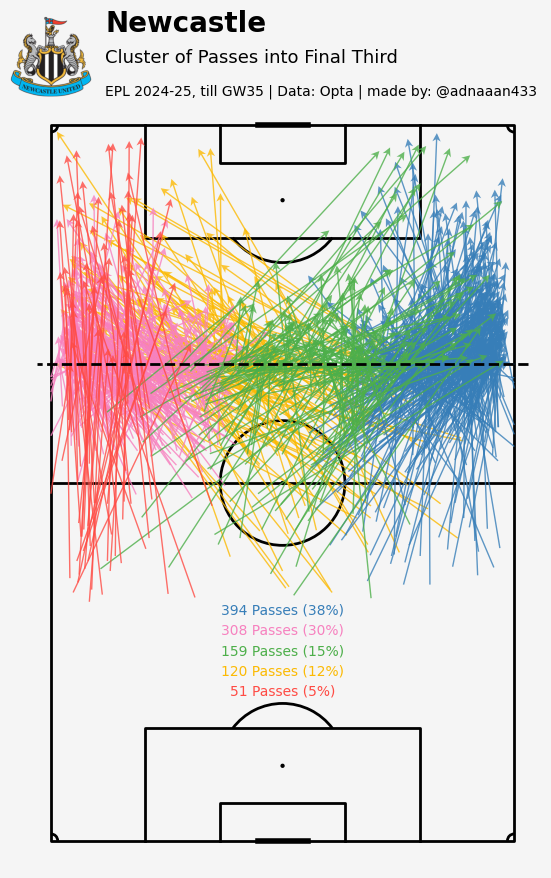

In [126]:
fig,ax = plt.subplots(figsize=(10,10), facecolor=bg_color)
plot_fentry_pass(ax, 'Newcastle')